# LOS Category Validation

This notebook checks whether the project target definition is reasonable for ICU length-of-stay classification.

Current project categories:

| Class | Definition | Interpretation |
| --- | --- | --- |
| 0 | LOS `< 2` days | Short ICU stay |
| 1 | `2 <= LOS <= 7` days | Typical/intermediate ICU stay |
| 2 | LOS `> 7` days | Prolonged ICU stay |

Comparison categories inspired by a paper:

| Class | Definition | Interpretation |
| --- | --- | --- |
| 0 | LOS `<= 7` days | Short |
| 1 | `7 < LOS <= 14` days | Medium |
| 2 | LOS `> 14` days | Long |

The goal is not to prove one definition is universally correct. The goal is to check whether the current definition has clinical interpretability, adequate class support, stable patient-level splits, and a less sparse prolonged-stay class for modeling.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data.splitting import assert_patient_split_integrity, patient_level_split

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

FIGURE_DIR = ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def load_icu_los_source(root: Path) -> pd.DataFrame:
    """Load stay-level LOS values used only for target-definition validation."""
    raw_csv = root / "data" / "raw" / "icustays.csv"
    raw_gz = root / "data" / "raw" / "icustays.csv.gz"
    processed = root / "data" / "processed" / "modeling_dataset.parquet"

    required = ["subject_id", "hadm_id", "stay_id", "los"]
    if raw_csv.exists():
        df = pd.read_csv(raw_csv, usecols=required)
        source = raw_csv
    elif raw_gz.exists():
        df = pd.read_csv(raw_gz, usecols=required)
        source = raw_gz
    elif processed.exists():
        df = pd.read_parquet(processed)
        missing = set(required).difference(df.columns)
        if missing:
            raise FileNotFoundError(
                "Could not find raw icustays data, and processed data is missing "
                f"the columns needed for LOS validation: {sorted(missing)}"
            )
        df = df[required].copy()
        source = processed
    else:
        raise FileNotFoundError(
            "Expected data/raw/icustays.csv, data/raw/icustays.csv.gz, or "
            "data/processed/modeling_dataset.parquet with LOS values."
        )

    df["los"] = pd.to_numeric(df["los"], errors="coerce")
    df = df.dropna(subset=["subject_id", "stay_id", "los"]).copy()
    df = df[df["los"] >= 0].copy()
    print(f"Loaded {len(df):,} ICU stays from {source.relative_to(root)}")
    return df

stays = load_icu_los_source(ROOT)
stays.head()

Loaded 94,444 ICU stays from data/raw/icustays.csv


,subject_id,hadm_id,stay_id,los
0,10000032,29079034,39553978,0.410266
1,10000690,25860671,37081114,3.893252
2,10000980,26913865,39765666,0.497535
3,10001217,24597018,37067082,1.118032
4,10001217,27703517,34592300,0.948113


In [3]:
CURRENT_LABELS = {
    0: "Class 0: <2 days",
    1: "Class 1: 2-7 days",
    2: "Class 2: >7 days",
}

PAPER_STYLE_LABELS = {
    0: "Short: <=7 days",
    1: "Medium: 7-14 days",
    2: "Long: >14 days",
}


def assign_current_los_category(los: pd.Series) -> pd.Series:
    return pd.Series(
        np.select([los < 2, los <= 7], [0, 1], default=2),
        index=los.index,
        dtype="int64",
    )


def assign_paper_style_los_category(los: pd.Series) -> pd.Series:
    return pd.Series(
        np.select([los <= 7, los <= 14], [0, 1], default=2),
        index=los.index,
        dtype="int64",
    )


stays["current_category"] = assign_current_los_category(stays["los"])
stays["paper_style_category"] = assign_paper_style_los_category(stays["los"])

stays[["subject_id", "stay_id", "los", "current_category", "paper_style_category"]].head()

,subject_id,stay_id,los,current_category,paper_style_category
0,10000032,39553978,0.410266,0,0
1,10000690,37081114,3.893252,1,0
2,10000980,39765666,0.497535,0,0
3,10001217,37067082,1.118032,0,0
4,10001217,34592300,0.948113,0,0


In [4]:
def category_summary(df: pd.DataFrame, category_col: str, labels: dict[int, str], scheme_name: str) -> pd.DataFrame:
    counts = df[category_col].value_counts().sort_index()
    summary = pd.DataFrame({
        "scheme": scheme_name,
        "class": counts.index,
        "label": [labels[int(value)] for value in counts.index],
        "count": counts.to_numpy(),
    })
    summary["percent"] = 100 * summary["count"] / len(df)
    return summary

current_summary = category_summary(stays, "current_category", CURRENT_LABELS, "Current: <2, 2-7, >7")
paper_summary = category_summary(stays, "paper_style_category", PAPER_STYLE_LABELS, "Paper-style: <=7, 7-14, >14")
category_comparison = pd.concat([current_summary, paper_summary], ignore_index=True)

styled_summary = category_comparison.copy()
styled_summary["percent"] = styled_summary["percent"].round(2)
display(styled_summary)

,scheme,class,label,count,percent
0,"Current: <2, 2-7, >7",0,Class 0: <2 days,48107,50.94
1,"Current: <2, 2-7, >7",1,Class 1: 2-7 days,35166,37.23
2,"Current: <2, 2-7, >7",2,Class 2: >7 days,11171,11.83
3,"Paper-style: <=7, 7-14, >14",0,Short: <=7 days,83273,88.17
4,"Paper-style: <=7, 7-14, >14",1,Medium: 7-14 days,7274,7.70
5,"Paper-style: <=7, 7-14, >14",2,Long: >14 days,3897,4.13


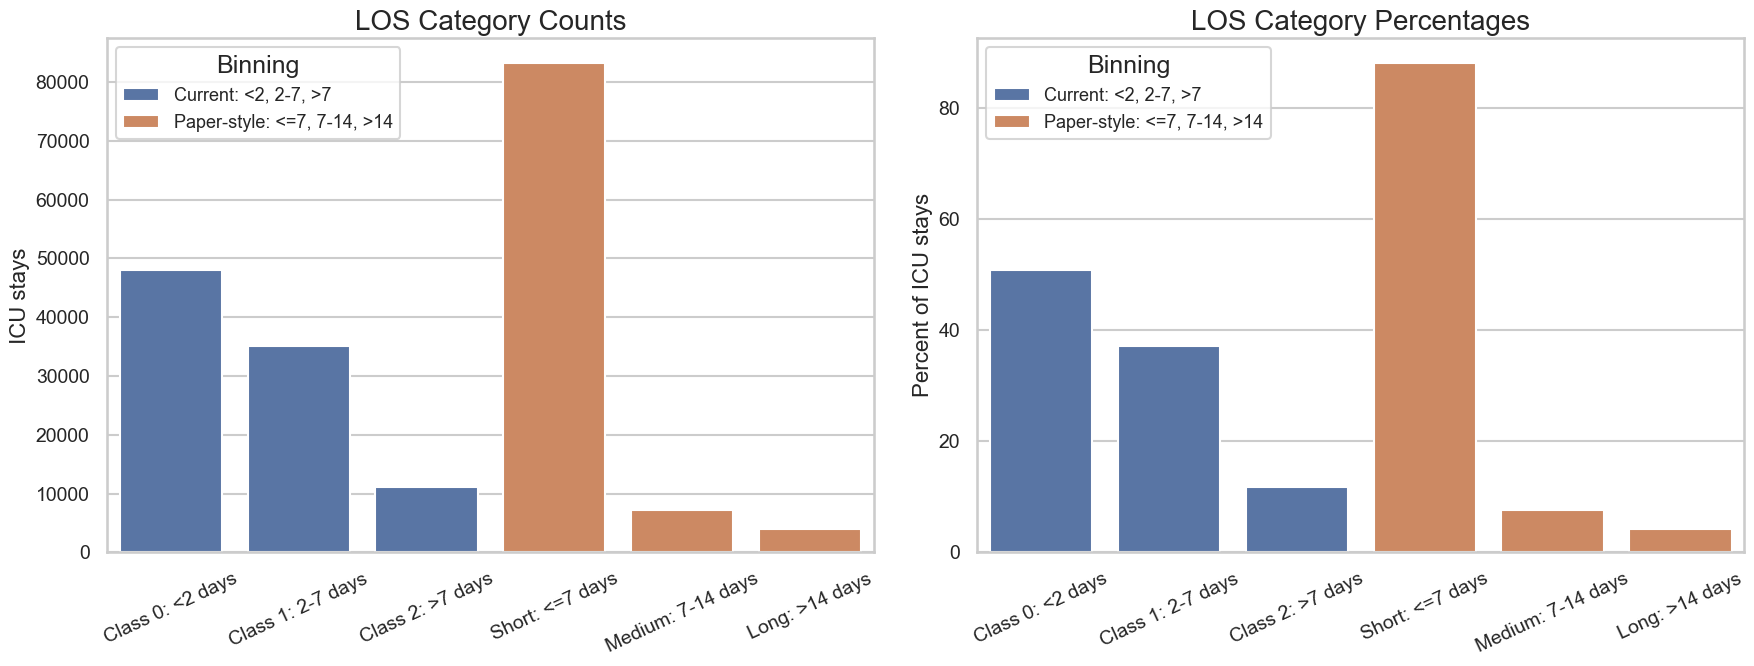

In [5]:
plot_df = category_comparison.copy()
plot_df["display_label"] = plot_df["label"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=plot_df, x="display_label", y="count", hue="scheme", ax=axes[0])
axes[0].set_title("LOS Category Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("ICU stays")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Binning")

sns.barplot(data=plot_df, x="display_label", y="percent", hue="scheme", ax=axes[1])
axes[1].set_title("LOS Category Percentages")
axes[1].set_xlabel("")
axes[1].set_ylabel("Percent of ICU stays")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Binning")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "los_category_distribution_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Patient-Level Split Stability

A target definition is easier to defend when each class has enough examples in train, validation, and test after patient-level splitting. This mirrors the actual modeling pipeline and checks that the minority class does not become too sparse in any held-out split.

In [6]:
split_df = stays.copy()
split_df["split"] = patient_level_split(split_df, subject_col="subject_id", test_size=0.15, val_size=0.15, random_state=42)
assert_patient_split_integrity(split_df, subject_col="subject_id", split_col="split")
print("Patient-level split integrity check passed: no subject_id appears in more than one split.")


def split_category_summary(df: pd.DataFrame, category_col: str, labels: dict[int, str], scheme_name: str) -> pd.DataFrame:
    grouped = df.groupby(["split", category_col], observed=True).size().rename("count").reset_index()
    grouped = grouped.rename(columns={category_col: "class"})
    split_sizes = df.groupby("split").size().rename("split_total")
    grouped = grouped.merge(split_sizes, on="split", how="left")
    grouped["percent_within_split"] = 100 * grouped["count"] / grouped["split_total"]
    grouped["label"] = grouped["class"].map(labels)
    grouped["scheme"] = scheme_name
    return grouped

split_comparison = pd.concat([
    split_category_summary(split_df, "current_category", CURRENT_LABELS, "Current: <2, 2-7, >7"),
    split_category_summary(split_df, "paper_style_category", PAPER_STYLE_LABELS, "Paper-style: <=7, 7-14, >14"),
], ignore_index=True)

split_table = split_comparison[["scheme", "split", "label", "count", "percent_within_split"]].copy()
split_table["percent_within_split"] = split_table["percent_within_split"].round(2)
display(split_table.sort_values(["scheme", "split", "label"]))

Patient-level split integrity check passed: no subject_id appears in more than one split.


,scheme,split,label,count,percent_within_split
0,"Current: <2, 2-7, >7",test,Class 0: <2 days,7243,50.80
1,"Current: <2, 2-7, >7",test,Class 1: 2-7 days,5310,37.24
2,"Current: <2, 2-7, >7",test,Class 2: >7 days,1704,11.95
3,"Current: <2, 2-7, >7",train,Class 0: <2 days,33644,50.86
4,"Current: <2, 2-7, >7",train,Class 1: 2-7 days,24773,37.45
5,"Current: <2, 2-7, >7",train,Class 2: >7 days,7734,11.69
6,"Current: <2, 2-7, >7",val,Class 0: <2 days,7220,51.44
7,"Current: <2, 2-7, >7",val,Class 1: 2-7 days,5083,36.21
8,"Current: <2, 2-7, >7",val,Class 2: >7 days,1733,12.35
11,"Paper-style: <=7, 7-14, >14",test,Long: >14 days,625,4.38


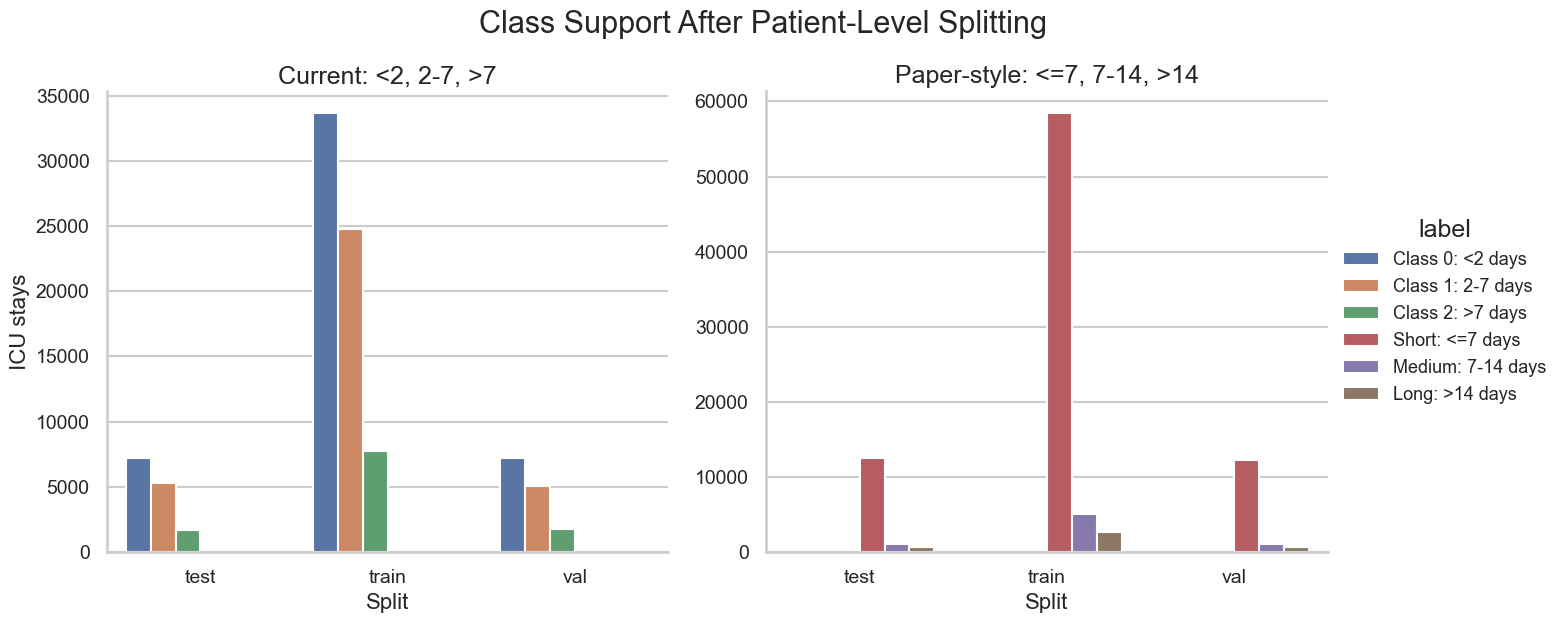

In [7]:
g = sns.catplot(
    data=split_comparison,
    kind="bar",
    x="split",
    y="count",
    hue="label",
    col="scheme",
    height=6,
    aspect=1.15,
    sharey=False,
)
g.set_axis_labels("Split", "ICU stays")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=0)
    ax.set_title(ax.get_title(), fontsize=18)
g.fig.suptitle("Class Support After Patient-Level Splitting", y=1.05, fontsize=22)
g.fig.savefig(FIGURE_DIR / "los_category_split_support.png", dpi=200, bbox_inches="tight")
plt.show()

## Modeling Practicality Checks

The current bins are easier to justify if they avoid an extremely sparse long-stay class. The checks below compare minority-class support, long-class support, and the ratio between the largest and smallest class.

In [8]:
def binning_diagnostics(summary: pd.DataFrame) -> pd.Series:
    smallest = summary.loc[summary["count"].idxmin()]
    largest = summary.loc[summary["count"].idxmax()]
    long_class = summary.loc[summary["class"].eq(2)].iloc[0]
    return pd.Series({
        "smallest_class": smallest["label"],
        "smallest_count": int(smallest["count"]),
        "smallest_percent": smallest["percent"],
        "largest_to_smallest_ratio": largest["count"] / smallest["count"],
        "long_class": long_class["label"],
        "long_count": int(long_class["count"]),
        "long_percent": long_class["percent"],
    })

diagnostics = pd.DataFrame({
    "Current: <2, 2-7, >7": binning_diagnostics(current_summary),
    "Paper-style: <=7, 7-14, >14": binning_diagnostics(paper_summary),
}).T

display(diagnostics.round({
    "smallest_percent": 2,
    "largest_to_smallest_ratio": 2,
    "long_percent": 2,
}))

,smallest_class,smallest_count,smallest_percent,largest_to_smallest_ratio,long_class,long_count,long_percent
"Current: <2, 2-7, >7",Class 2: >7 days,11171,11.828173,4.306418,Class 2: >7 days,11171,11.828173
"Paper-style: <=7, 7-14, >14",Long: >14 days,3897,4.126255,21.368489,Long: >14 days,3897,4.126255


In [9]:
current_long = current_summary.loc[current_summary["class"].eq(2), "percent"].iloc[0]
paper_long = paper_summary.loc[paper_summary["class"].eq(2), "percent"].iloc[0]
paper_long_count = paper_summary.loc[paper_summary["class"].eq(2), "count"].iloc[0]

if paper_long < 5 or paper_long_count < 500:
    recommendation = (
        "The paper-style >14 day long-stay class is relatively sparse in this cohort. "
        "The current >7 day long-stay threshold is more practical for stable multiclass modeling."
    )
elif current_long > paper_long * 1.5:
    recommendation = (
        "The current >7 day long-stay class has substantially more support than the >14 day alternative, "
        "which should make long-stay recall and macro-averaged metrics more stable."
    )
else:
    recommendation = (
        "Both target definitions appear to have usable long-class support. In that case, the final choice "
        "should be based on the clinical question: early prolonged-stay detection (>7 days) versus very "
        "prolonged-stay detection (>14 days)."
    )

print(recommendation)

The paper-style >14 day long-stay class is relatively sparse in this cohort. The current >7 day long-stay threshold is more practical for stable multiclass modeling.


## Current Model Context

If saved reports are available, the cell below loads the existing current-category test metrics. These metrics should be interpreted together with the class-support checks above.

In [10]:
metrics_path = ROOT / "reports" / "classification" / "icu_los_classifier" / "test_metrics.json"
if metrics_path.exists():
    with metrics_path.open() as f:
        metrics = json.load(f)
    metrics_summary = pd.DataFrame([
        {
            "macro_f1": metrics.get("macro_f1"),
            "weighted_f1": metrics.get("weighted_f1"),
            "balanced_accuracy": metrics.get("balanced_accuracy"),
            "roc_auc_ovr_macro": metrics.get("roc_auc_ovr_macro"),
            "roc_auc_ovr_weighted": metrics.get("roc_auc_ovr_weighted"),
        }
    ])
    display(metrics_summary.round(3))
else:
    print(f"No saved current-category test metrics found at {metrics_path.relative_to(ROOT)}")

,macro_f1,weighted_f1,balanced_accuracy,roc_auc_ovr_macro,roc_auc_ovr_weighted
0,0.59,0.64,0.617,0.814,0.807


## Suggested Report Language

The current target definition is defensible if the tables above show materially better long-class support than the paper-style `>14` day definition:

> LOS categories were selected to distinguish short ICU stays (`<2` days), typical ICU stays (`2-7` days), and prolonged ICU stays (`>7` days) while preserving enough examples per class for multiclass evaluation. We compared this definition against a paper-style threshold of `<=7`, `7-14`, and `>14` days. In this ICU cohort, the `>14` day group is smaller, which can make long-stay recall and macro-averaged metrics less stable. The selected `<2`, `2-7`, `>7` day definition therefore provides a clinically interpretable and statistically practical target for this dataset.